# Analysis of the minimap output from flye assemblies and reference genome

Notes - https://docs.google.com/document/d/1UwfG-clsAUK8n0zq_ujWmCMoOYx3PKVOOspuUA4Audg/edit?tab=t.ut74az557twd

In [18]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

In [2]:
pafFilename = "../Mildew/air_mildew_mapping/mildew_air_mapping.paf"

In [3]:
def get_group(contig):
    if contig.startswith("flye_ass01_"):
        return "Assembly_01"
    elif contig.startswith("flye_ass02_"):
        return "Assembly_02"
    elif contig.startswith("flye_ass03_"):
        return "Assembly_03"
    elif contig.startswith("flye_ass04_"):
        return "Assembly_04"
    else:
        return "Reference"

class alignment_info:
    def __init__(self, q_name, contig, match_bases, map_length, identity, MQ):
        self.q_name = q_name
        self.contig = contig
        self.group = get_group(contig)
        self.match_bases = match_bases
        self.map_length = map_length
        self.identity = identity
        self.MQ = MQ

    def print_alignment(self):
        print(f"Query: {self.q_name}, Group: {self.group}, Identity: {self.identity}, MQ: {self.MQ}")

alignments = {}
with open(pafFilename, 'r') as pafFile:
    for line in pafFile:
        fields = line.strip().split('\t')
        q_name = fields[0].strip()
        contig = fields[5].strip()
        match_bases = int(fields[9].strip())
        map_length = int(fields[10].strip())
        identity = (match_bases / map_length) * 100 if map_length > 0 else 0
        MQ = int(fields[11].strip())
        ai = alignment_info(q_name, contig, match_bases, map_length, identity, MQ)
        if q_name not in alignments:
            alignments[q_name] = []
        alignments[q_name].append(ai)

## Looking into best hits

Filtering on mapping length and identity then counting how many alignments there are

In [4]:
def passes_filters(aln, min_len=150, min_id=80, tags=None):
    # tags is the list of optional PAF tags for this alignment if you capture them
    if aln.map_length < min_len:
        return False
    if min_id is not None and aln.identity < min_id:
        return False
    return True

# collect filtered alignments per read
filtered = {}
with open(pafFilename) as fh:
    for line in fh:
        f = line.rstrip("\n").split("\t")
        q = f[0]
        t = f[5]
        match_bases = int(f[9])
        map_len = int(f[10])
        ident = (match_bases / map_len) * 100 if map_len > 0 else 0.0
        MQ = int(f[11])
        aln = alignment_info(q, t, match_bases, map_len, ident, MQ)
        if passes_filters(aln, min_len=150, min_id=80):
            filtered.setdefault(q, []).append(aln)

# Count filtered alignments per group
from collections import Counter
filtered_group_counts = Counter()
for align_list in filtered.values():
    for aln in align_list:
        filtered_group_counts[aln.group] += 1

print("Filtered alignment counts per group:")
for group, count in filtered_group_counts.items():
    print(f"{group}: {count}")

Filtered alignment counts per group:
Reference: 204
Assembly_03: 151
Assembly_02: 3295
Assembly_04: 1033
Assembly_01: 376


## Plotting

### Length of alignments

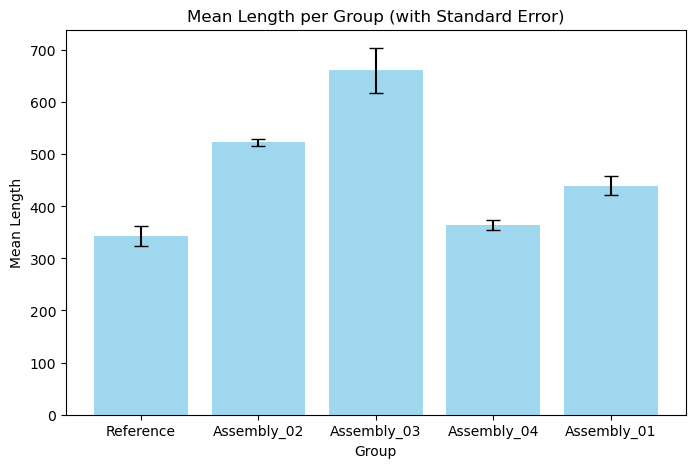

In [ ]:
# Collect lengths per group
group_lengths = {}
for align_list in alignments.values():
    for ai in align_list:
        group_lengths.setdefault(ai.group, []).append(ai.map_length)

# Calculate mean and standard error per group
mean_lengths = {g: np.mean(vals) for g, vals in group_lengths.items()}
stderr_lengths = {g: np.std(vals, ddof=1)/np.sqrt(len(vals)) for g, vals in group_lengths.items()}

groups = list(mean_lengths.keys())
means = [mean_lengths[g] for g in groups]
stderrs = [stderr_lengths[g] for g in groups]

plt.figure(figsize=(8,5))
plt.bar(groups, means, yerr=stderrs, capsize=5, color='skyblue', alpha=0.8)
plt.ylabel('Mean Length (bp)')
plt.xlabel('Group')
plt.title('Mean Length per Group (with Standard Error)')
plt.show()

### Mean identity 

In [43]:
# Unfiltered identities per group
group_identities_unfiltered = {}
for align_list in alignments.values():
    for ai in align_list:
        group_identities_unfiltered.setdefault(ai.group, []).append(ai.identity)

# Filtered identities per group (MQ == 0 or MQ > 5)
group_identities_filtered = {}
for align_list in alignments.values():
    for ai in align_list:
        if ai.MQ == 0 or ai.MQ > 5:
            group_identities_filtered.setdefault(ai.group, []).append(ai.identity)


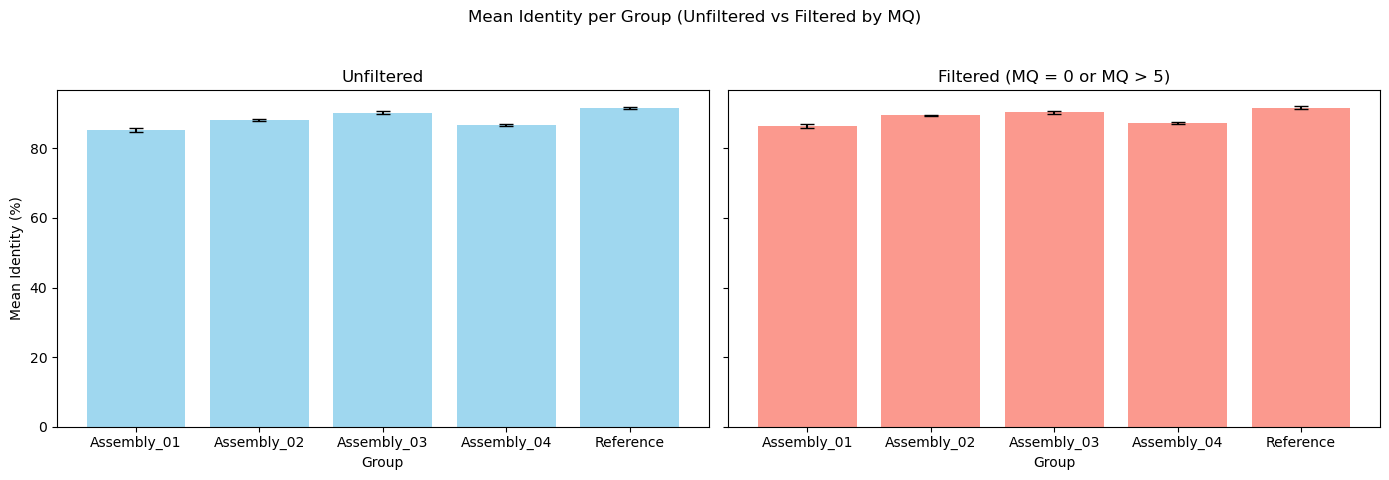

In [ ]:

def get_means_stderr(group_identities):
    means = {g: np.mean(vals) for g, vals in group_identities.items()}
    stderrs = {g: np.std(vals, ddof=1)/np.sqrt(len(vals)) for g, vals in group_identities.items()}
    return means, stderrs

means_unfiltered, stderrs_unfiltered = get_means_stderr(group_identities_unfiltered)
means_filtered, stderrs_filtered = get_means_stderr(group_identities_filtered)

groups = sorted(set(list(means_unfiltered.keys()) + list(means_filtered.keys())))
means_unf = [means_unfiltered.get(g, 0) for g in groups]
stderrs_unf = [stderrs_unfiltered.get(g, 0) for g in groups]
means_filt = [means_filtered.get(g, 0) for g in groups]
stderrs_filt = [stderrs_filtered.get(g, 0) for g in groups]

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].bar(groups, means_unf, yerr=stderrs_unf, capsize=5, color='skyblue', alpha=0.8)
axes[0].set_title('Unfiltered')
axes[0].set_ylabel('Mean Identity (%)')
axes[0].set_xlabel('Group')
# axes[0].set_ylim(0, 1)

axes[1].bar(groups, means_filt, yerr=stderrs_filt, capsize=5, color='salmon', alpha=0.8)
axes[1].set_title('Filtered (MQ = 0 or MQ > 5)')
axes[1].set_xlabel('Group')
# axes[1].set_ylim(0, 1)

plt.suptitle('Mean Identity per Group (Unfiltered vs Filtered by MQ)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

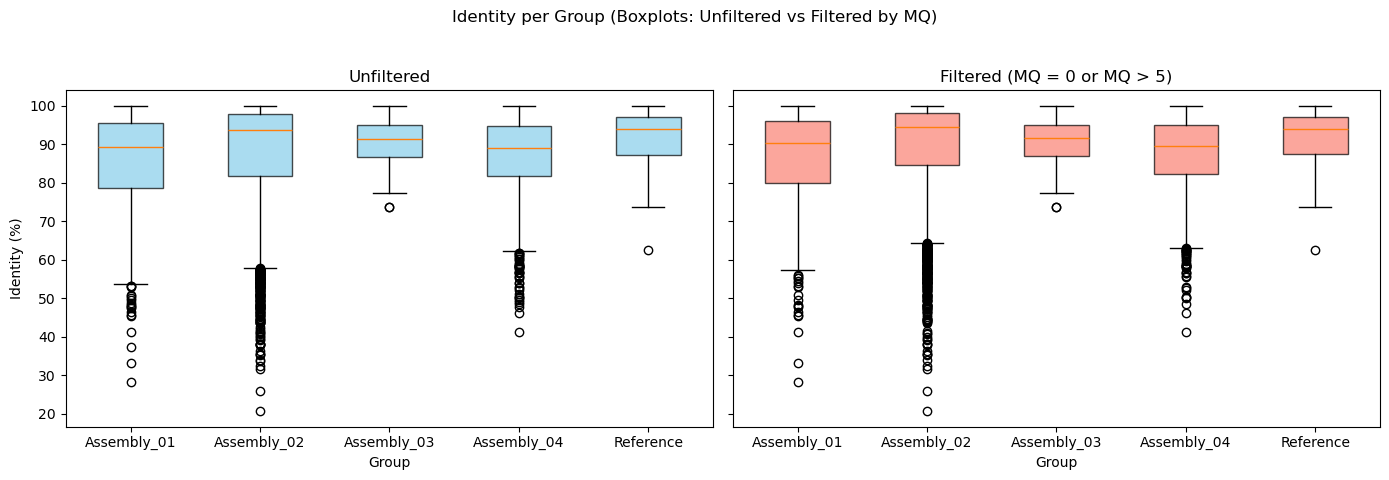

In [42]:

# Prepare data for boxplots
groups = sorted(set(list(group_identities_unfiltered.keys()) + list(group_identities_filtered.keys())))
data_unfiltered = [group_identities_unfiltered.get(g, []) for g in groups]
data_filtered = [group_identities_filtered.get(g, []) for g in groups]

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].boxplot(data_unfiltered, labels=groups, patch_artist=True, boxprops=dict(facecolor='skyblue', alpha=0.7))
axes[0].set_title('Unfiltered')
axes[0].set_ylabel('Identity (%)')
axes[0].set_xlabel('Group')

axes[1].boxplot(data_filtered, labels=groups, patch_artist=True, boxprops=dict(facecolor='salmon', alpha=0.7))
axes[1].set_title('Filtered (MQ = 0 or MQ > 5)')
axes[1].set_xlabel('Group')

plt.suptitle('Identity per Group (Boxplots: Unfiltered vs Filtered by MQ)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

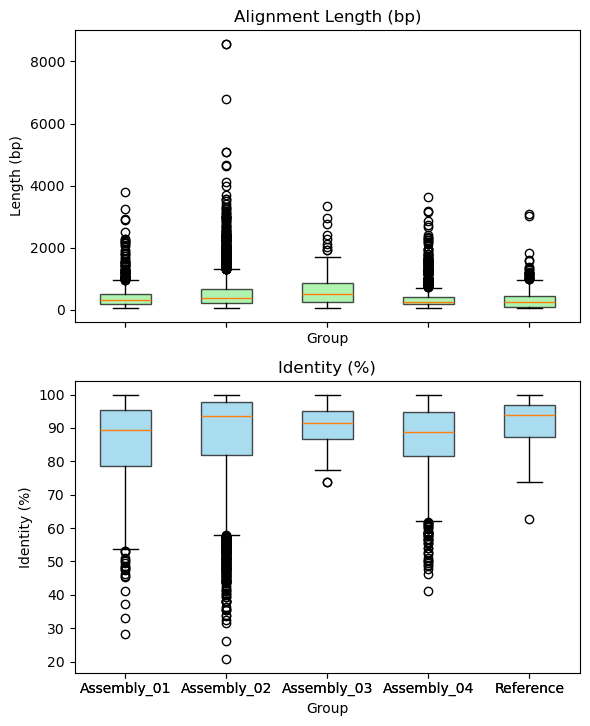

In [47]:
# Prepare data for boxplots (unfiltered)
groups = sorted(group_identities_unfiltered.keys())
data_identity = [group_identities_unfiltered.get(g, []) for g in groups]
data_length = [[ai.map_length for align_list in alignments.values() for ai in align_list if ai.group == g] for g in groups]

fig, axes = plt.subplots(2, 1, figsize=(6,8), sharex=True)

axes[0].boxplot(data_length, labels=groups, patch_artist=True, boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[0].set_title('Alignment Length (bp)')
axes[0].set_ylabel('Length (bp)')
axes[0].set_xlabel('Group')

axes[1].boxplot(data_identity, labels=groups, patch_artist=True, boxprops=dict(facecolor='skyblue', alpha=0.7))
axes[1].set_title('Identity (%)')
axes[1].set_ylabel('Identity (%)')
axes[1].set_xlabel('Group')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Prepare dataframe for unfiltered data
data = []
for align_list in alignments.values():
    for ai in align_list:
        data.append({'Group': ai.group, 'Identity': ai.identity, 'Length': ai.map_length})
df = pd.DataFrame(data)

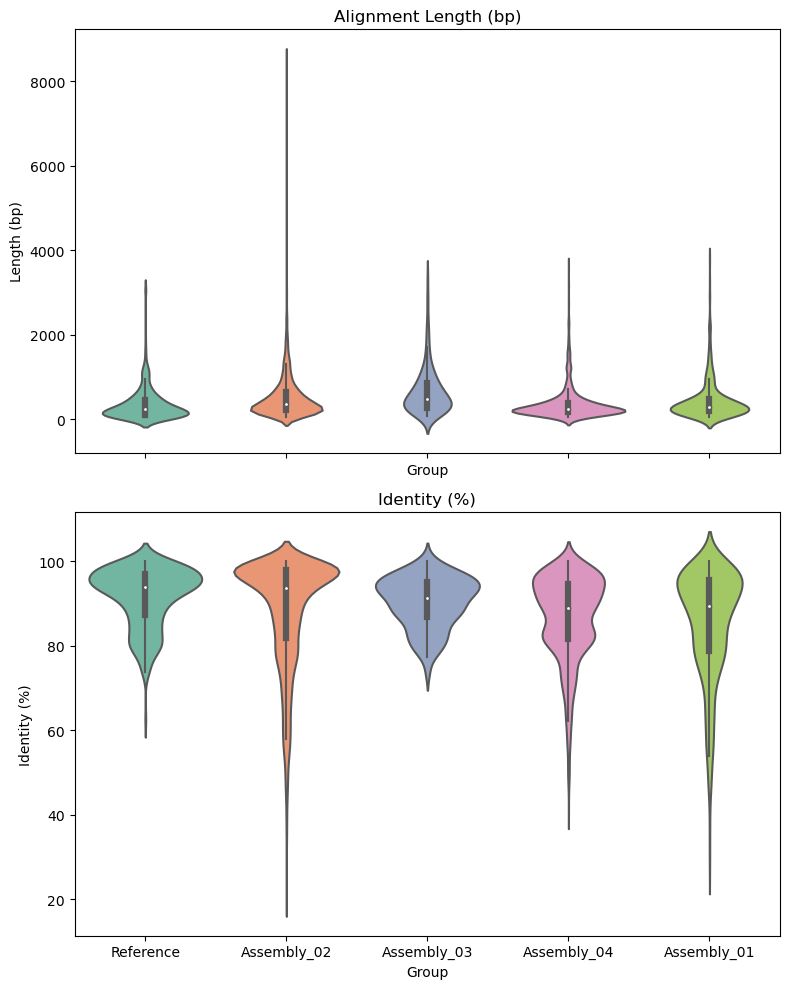

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8,10), sharex=True)

sns.violinplot(data=df, x='Group', y='Length', ax=axes[0], palette='Set2', inner='box')
axes[0].set_title('Alignment Length (bp)')
axes[0].set_ylabel('Length (bp)')

sns.violinplot(data=df, x='Group', y='Identity', ax=axes[1], palette='Set2', inner='box')
axes[1].set_title('Identity (%)')
axes[1].set_ylabel('Identity (%)')
axes[1].set_xlabel('Group')

plt.tight_layout()
plt.show()

/Users/berelsom/opt/anaconda3/envs/24hr_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/ns/9skdzql508n7rzzgbqpc2wpw000f7r/T/ipykernel_34212/2440515596.py:15: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),
/var/folders/ns/9skdzql508n7rzzgbqpc2wpw000f7r/T/ipykernel_34212/2440515596.py:15: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),


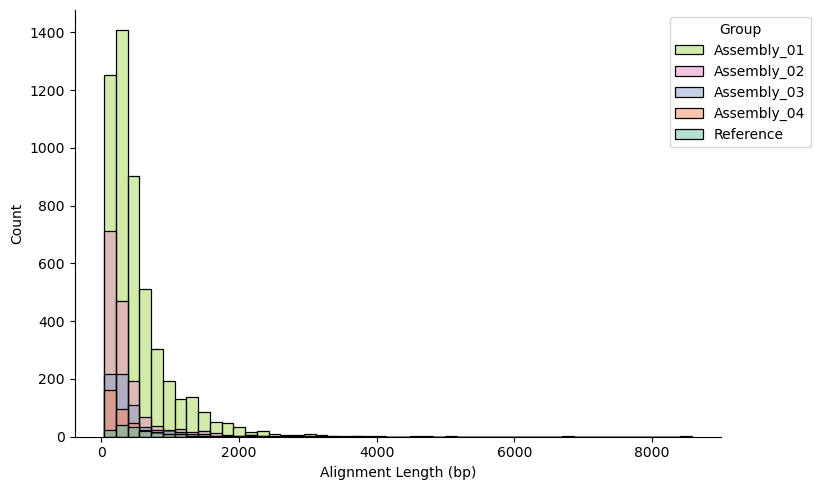

/Users/berelsom/opt/anaconda3/envs/24hr_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/ns/9skdzql508n7rzzgbqpc2wpw000f7r/T/ipykernel_34212/2440515596.py:29: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),
/var/folders/ns/9skdzql508n7rzzgbqpc2wpw000f7r/T/ipykernel_34212/2440515596.py:29: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),


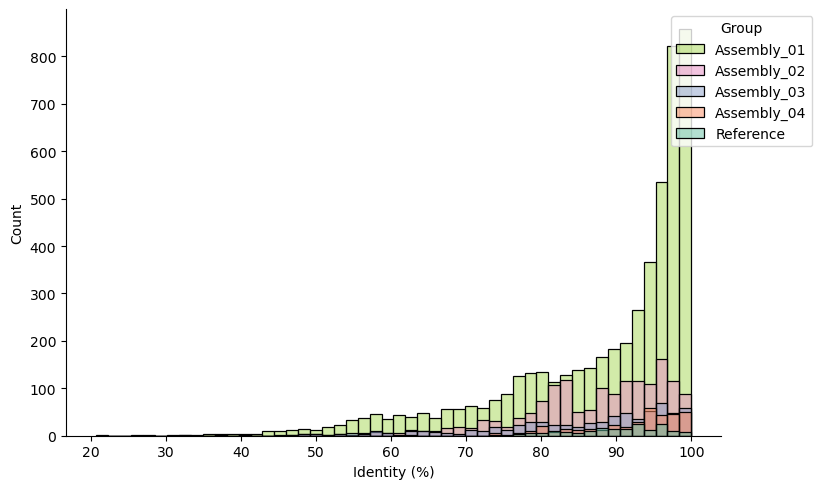

In [22]:
# Count number of samples per group
group_counts = df['Group'].value_counts()
ordered_groups = group_counts.sort_values().index.tolist()  # smallest first
alphabetical_groups = sorted(group_counts.index.tolist())   # alphabetical order

base_palette = sns.color_palette('Set2', len(ordered_groups))

# Layered histogram for alignment length
g = sns.displot(
    data=df, x='Length', hue='Group', kind='hist', multiple='layer',
    palette=base_palette, aspect=1.5, height=5, bins=50, hue_order=ordered_groups
)
g._legend.remove()  # Remove default legend
handles, labels = g.ax.get_legend_handles_labels()
g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),
            labels=alphabetical_groups)  # Set legend labels in alphabetical order

plt.xlabel('Alignment Length (bp)')
plt.ylabel('Count')
plt.show()

# Layered histogram for identity
g = sns.displot(
    data=df, x='Identity', hue='Group', kind='hist', multiple='layer',
    palette=base_palette, aspect=1.5, height=5, bins=50, hue_order=ordered_groups
)
g._legend.remove()
handles, labels = g.ax.get_legend_handles_labels()
g.ax.legend(handles, labels, title='Group', loc='upper right', frameon=True, bbox_to_anchor=(1.15, 1),
            labels=alphabetical_groups)

plt.xlabel('Identity (%)')
plt.ylabel('Count')
plt.show()